In [1]:

import matplotlib.pyplot as plt
'''
Model with function to load artefact data from Excel .xls and .xlsx files and splits 
data in separate vectors to process. Written for KT3401 - Assignment Artefact Detection
'''
# #%% Clear system
# from IPython import get_ipython
# # Clear all variables (IPython/Jupyter)
# get_ipython().magic('reset -sf')
# import matplotlib.pyplot as plt
# # Close all figures
# plt.close('all')
# import os
# # Clear the console
# os.system('cls' if os.name == 'nt' else 'clear')

#%% Import modules
import pandas as pd
import numpy as np 
import os

def read_Artefacts(path, folder, filename, fs):
    """
    Inputs: 
    path: string to the path with data folders
    folder: string with the name of the folder with the dataset
    filename: string with name of the file, incl. extension
    fs: sampling rate (in Hz)

    Outputs: 
    t: time vector based on length of signal (to use instead of Time)
    ABP, CVP: vectors of arterial blood pressure and central venous pressure, with same length as t
    """
    filepath = os.path.join(path, folder, filename)
    print(f"Attempting to read file at: {filepath}")  # Debug print statement
    # Read the Excel file
    try:
        raw = pd.read_excel(filepath, sheet_name=0, header=None)
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None, None, None
    raw = pd.read_excel(filepath, sheet_name=0, header=None)
    
    # Skip the first two rows
    raw = raw.iloc[2:, :]
    
    # Convert the data to a numpy array
    data = raw.to_numpy()
    
    # Allocate imported array to column variable names
    ABP = pd.to_numeric(data[:, 1], errors = 'coerce')
    CVP = pd.to_numeric(data[:, 2], errors = 'coerce')
    
    # Create time vector
    t = np.arange(1/fs, len(ABP)/fs + 1/fs, 1/fs)

    return t, ABP, CVP






In [3]:
if __name__ == "__main__":

# Load data
    path = "C:\\Users\\Mila den Hollander\\OneDrive - Delft University of Technology\\Bureaublad\\KT3405 Intensive care en computer simulatie\\KT3401_AFdata_2025"
    folder = "Slinger"
    filename = "D01Slinger.xlsx"
    fs = 100
    filenames= ["D01Slinger.xlsx", "D02Slinger.xlsx", "D03Slinger.xlsx", "D05Slinger.xlsx", "D06Slinger.xlsx"]


    t, ABP, CVP = read_Artefacts(path, folder, filename, fs) 

Attempting to read file at: C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025\Slinger\D01Slinger.xlsx


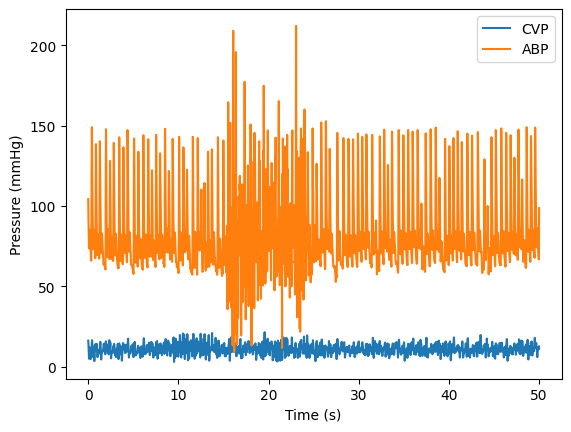

In [4]:
if t is not None and CVP is not None:
    plt.plot(t, CVP, label='CVP')
    plt.plot(t, ABP, label='ABP')
    plt.xlabel('Time (s)')
    plt.ylabel('Pressure (mmHg)')
    plt.legend()
    plt.show()
else:
    print("Unable to plot because the data could not be loaded.")

In [5]:
import numpy as np
import pandas as pd
from scipy.signal import spectrogram


def _maak_minimale_duur_mask(mask, min_samples):
    """
    Houd alleen stukken over waar minstens min_samples opeenvolgende True's zitten.
    """
    mask = np.asarray(mask, dtype=bool)
    output = np.zeros_like(mask, dtype=bool)

    teller = 0
    for i, val in enumerate(mask):
        if val:
            teller += 1
        else:
            if teller >= min_samples:
                output[i - teller:i] = True
            teller = 0

    if teller >= min_samples:
        output[len(mask) - teller:len(mask)] = True

    return output


def _vind_segmenten(mask, t):
    """
    Zet boolean mask om naar start- en eindtijden.
    """
    mask = np.asarray(mask, dtype=int)
    padded = np.concatenate(([0], mask, [0]))
    dmask = np.diff(padded)

    start_idx = np.where(dmask == 1)[0]
    eind_idx = np.where(dmask == -1)[0] - 1

    start_tijden = t[start_idx]
    eind_tijden = t[eind_idx]

    return start_tijden, eind_tijden


def _voeg_dichte_segmenten_samen(start_tijden, eind_tijden, min_gap):
    """
    Voeg segmenten samen als de tussenruimte <= min_gap seconden is.
    """
    if len(start_tijden) == 0:
        return np.array([]), np.array([])

    nieuwe_starts = [start_tijden[0]]
    nieuwe_einden = [eind_tijden[0]]

    for i in range(1, len(start_tijden)):
        if start_tijden[i] - nieuwe_einden[-1] <= min_gap:
            nieuwe_einden[-1] = eind_tijden[i]
        else:
            nieuwe_starts.append(start_tijden[i])
            nieuwe_einden.append(eind_tijden[i])

    return np.array(nieuwe_starts), np.array(nieuwe_einden)


def _slinger_detectie_1_signaal(signaal, t, fs, frange, resolution,
                                drempel_factor, min_samples,
                                max_fraction, merge_gap):
    """
    Detecteer slinger in één signaal met spectrogram.
    """
    signaal = np.asarray(signaal, dtype=float)

    # Spectrogram
    frequenties, tijden, Sxx = spectrogram(
        signaal,
        fs=fs,
        nperseg=int(resolution * fs),
        noverlap=0,
        nfft=int(resolution * fs),
        scaling="spectrum",
        mode="magnitude"
    )

    # Kies interessante frequenties
    geselecteerd = (frequenties >= frange[0]) & (frequenties <= frange[1])

    if np.sum(geselecteerd) == 0:
        leeg_mask = np.zeros(len(t), dtype=bool)
        return leeg_mask, np.array([]), np.array([]), np.zeros(len(t))

    out = np.mean(np.abs(Sxx[geselecteerd, :]), axis=0)

    # Interpoleer terug naar lengte van t
    afwijkingen = np.interp(
        np.linspace(0, 1, len(t)),
        np.linspace(0, 1, len(out)),
        out
    )

    # Threshold
    drempelwaarde = np.mean(out) * drempel_factor
    mask = afwijkingen > drempelwaarde

    # Minimale duur afdwingen
    mask = _maak_minimale_duur_mask(mask, min_samples)

    # Verwerp als "bijna alles" positief is
    if np.sum(mask) > max_fraction * len(t):
        mask = np.zeros(len(t), dtype=bool)

    # Segmenten bepalen
    start_tijden, eind_tijden = _vind_segmenten(mask, t)

    # Segmenten samenvoegen als ze dicht bij elkaar liggen
    start_tijden, eind_tijden = _voeg_dichte_segmenten_samen(
        start_tijden, eind_tijden, min_gap=merge_gap
    )

    # Maak mask opnieuw op basis van samengevoegde segmenten
    nieuwe_mask = np.zeros(len(t), dtype=bool)
    for s, e in zip(start_tijden, eind_tijden):
        nieuwe_mask[(t >= s) & (t <= e)] = True

    return nieuwe_mask, start_tijden, eind_tijden, afwijkingen


def functie_slinger(t, ABP, CVP, fs=100):
    """
    Detecteer slingerartefacten in ABP en CVP met spectrogramanalyse.

    Output:
        artefacten_uit : pandas DataFrame
        binair_ABP : boolean mask voor ABP
        binair_CVP : boolean mask voor CVP
        afwijkingen_ABP : geïnterpoleerde spectrogrammaat voor ABP
        afwijkingen_CVP : geïnterpoleerde spectrogrammaat voor CVP
    """
    resolution = 1.0
    frange = (5, 20)

    artefact_rows = []

    # ABP
    binair_ABP, start_ABP, eind_ABP, afwijkingen_ABP = _slinger_detectie_1_signaal(
        signaal=ABP,
        t=t,
        fs=fs,
        frange=frange,
        resolution=resolution,
        drempel_factor=1.0,   # komt overeen met mean(out)
        min_samples=200,
        max_fraction=0.6,
        merge_gap=5.0
    )

    for s, e in zip(start_ABP, eind_ABP):
        artefact_rows.append([round(float(s), 2), round(float(e), 2), "Slinger", "ABP"])

    # CVP
    binair_CVP, start_CVP, eind_CVP, afwijkingen_CVP = _slinger_detectie_1_signaal(
        signaal=CVP,
        t=t,
        fs=fs,
        frange=frange,
        resolution=resolution,
        drempel_factor=1.3,   # komt overeen met mean(out_CVP)*1.3
        min_samples=200,
        max_fraction=0.7,
        merge_gap=2.0
    )

    for s, e in zip(start_CVP, eind_CVP):
        artefact_rows.append([round(float(s), 2), round(float(e), 2), "Slinger", "CVP"])

    artefacten_uit = pd.DataFrame(
        artefact_rows,
        columns=["Starttijd", "Eindtijd", "Naam van het artefact", "Signaal"]
    )

    return artefacten_uit, binair_ABP, binair_CVP, afwijkingen_ABP, afwijkingen_CVP

Attempting to read file at: C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025\Slinger\D01Slinger.xlsx
   Starttijd  Eindtijd Naam van het artefact Signaal
0      14.45     24.99               Slinger     ABP
1       8.87     13.97               Slinger     CVP


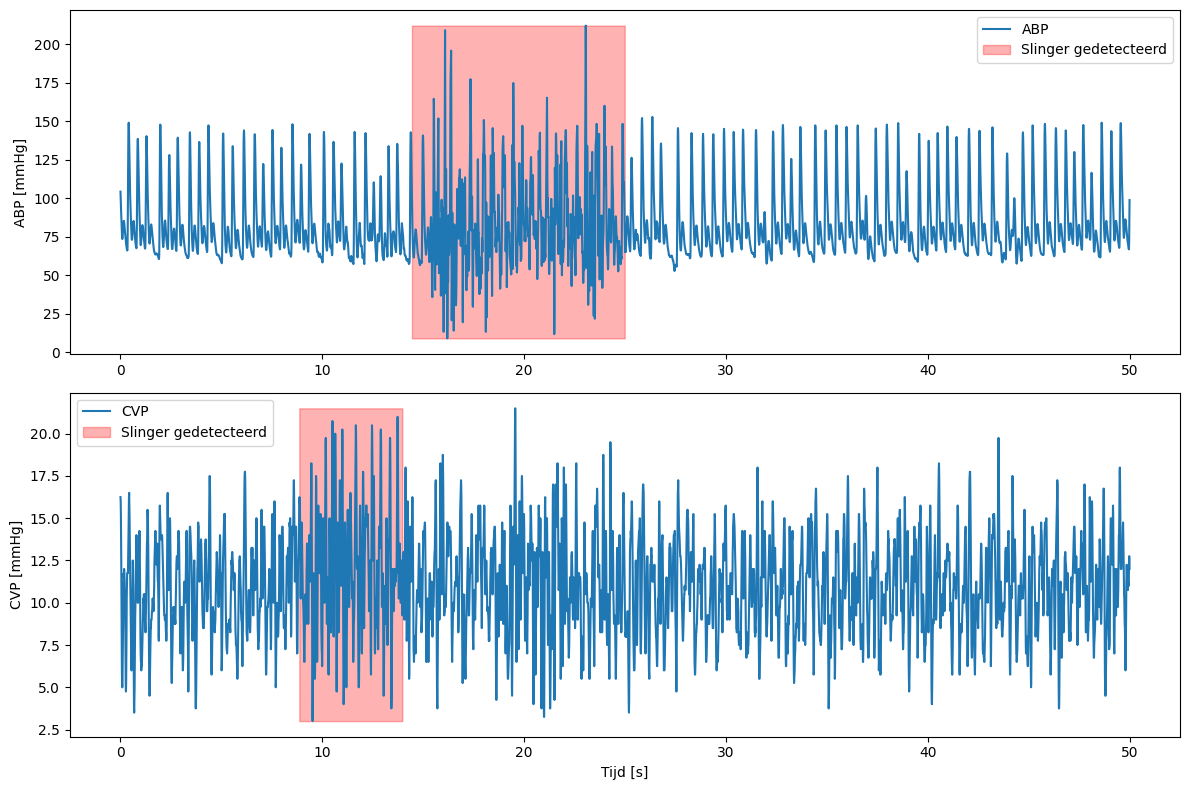

Attempting to read file at: C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025\Slinger\D02Slinger.xlsx
   Starttijd  Eindtijd Naam van het artefact Signaal
0       7.05     19.20               Slinger     ABP
1       7.38     19.25               Slinger     CVP


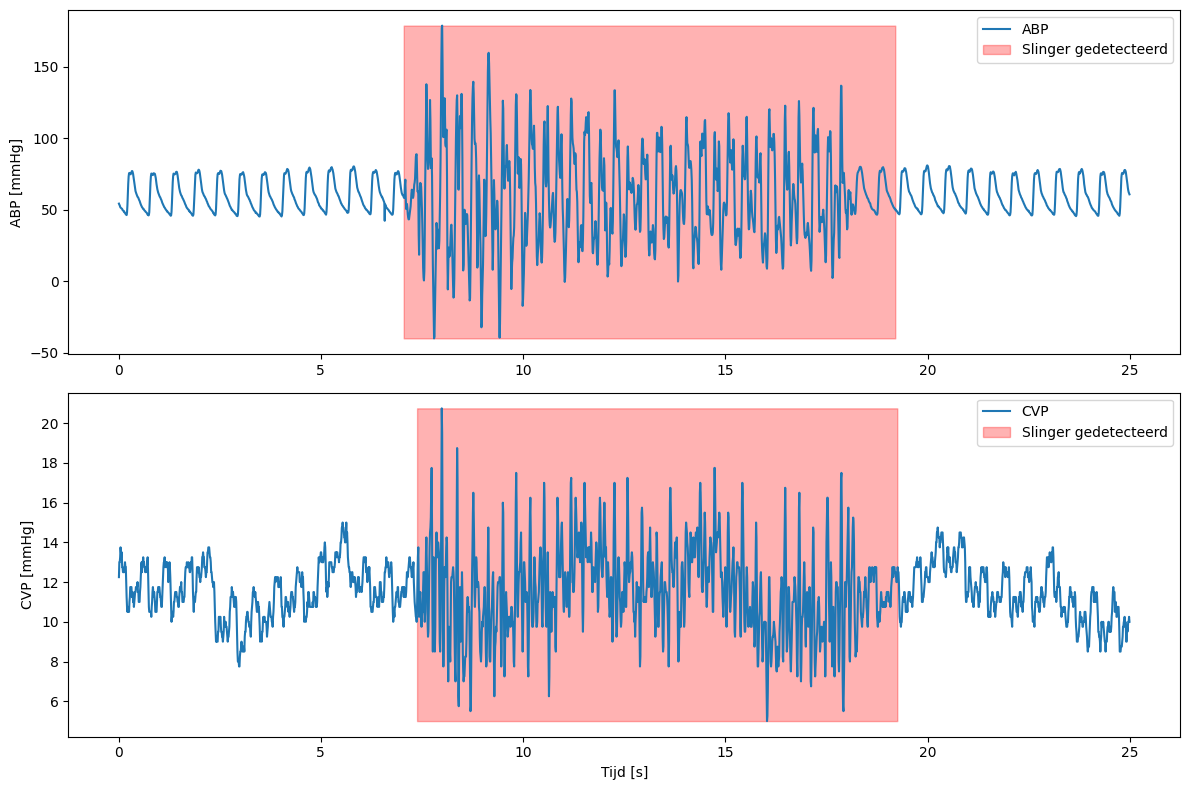

Attempting to read file at: C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025\Slinger\D03Slinger.xlsx
   Starttijd  Eindtijd Naam van het artefact Signaal
0      22.75     27.47               Slinger     ABP
1      40.97     45.78               Slinger     ABP
2      23.52     27.46               Slinger     CVP
3      41.00     45.75               Slinger     CVP


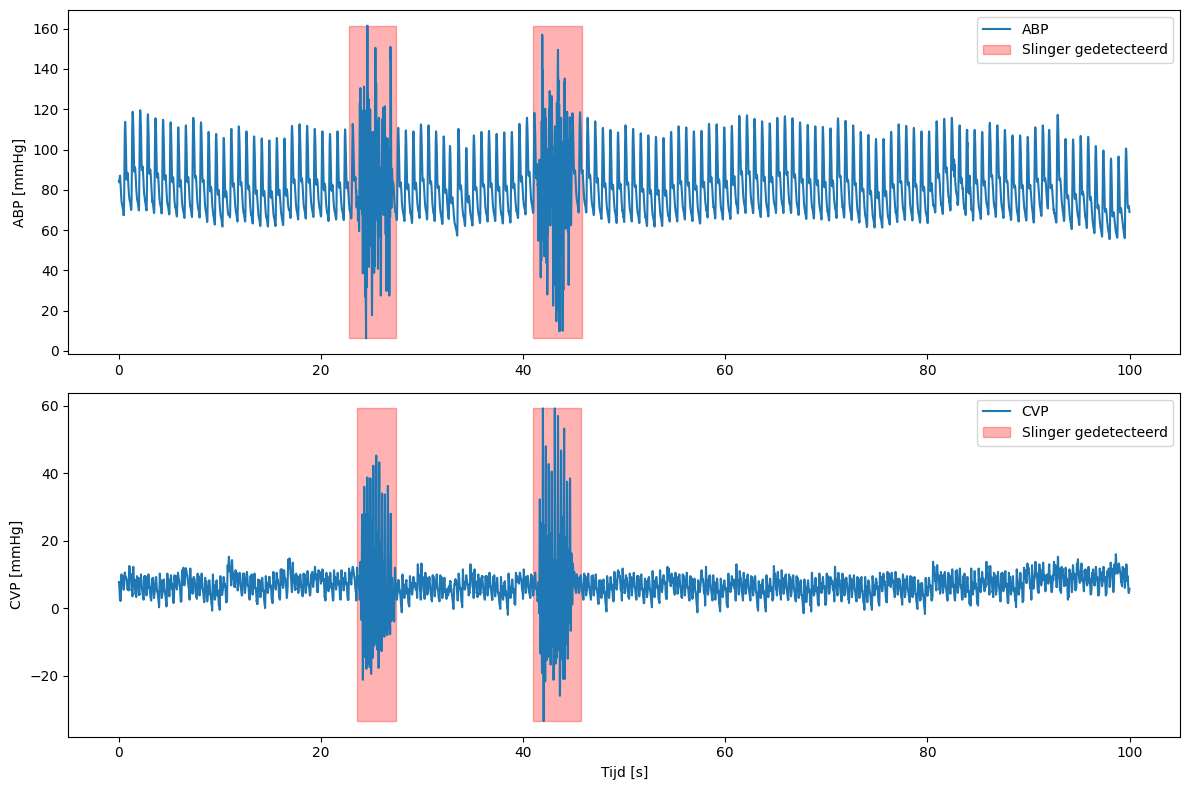

Attempting to read file at: C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025\Slinger\D05Slinger.xlsx
   Starttijd  Eindtijd Naam van het artefact Signaal
0      23.75     29.56               Slinger     ABP
1      55.92     61.18               Slinger     ABP
2      23.91     29.55               Slinger     CVP
3      56.27     61.14               Slinger     CVP


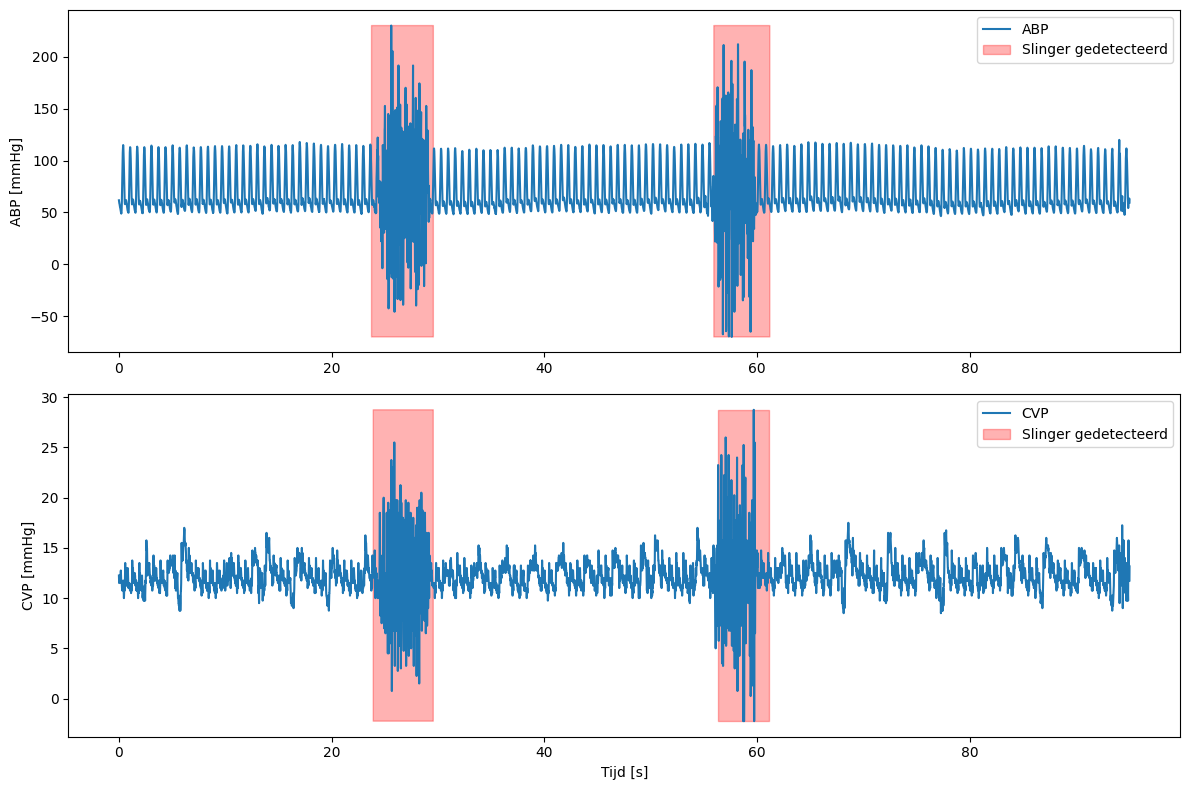

Attempting to read file at: C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025\Slinger\D06Slinger.xlsx
   Starttijd  Eindtijd Naam van het artefact Signaal
0      23.51     29.05               Slinger     ABP
1      54.70     60.63               Slinger     ABP
2      23.47     29.11               Slinger     CVP
3      54.85     60.53               Slinger     CVP


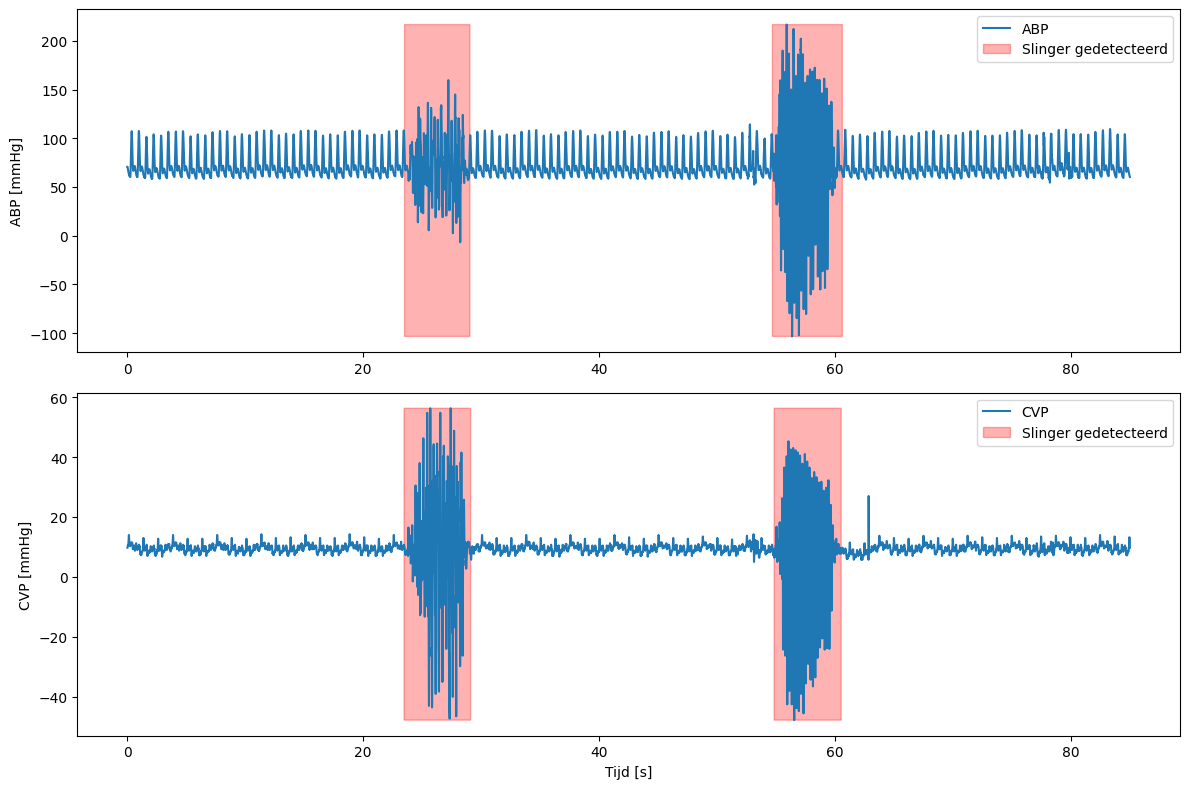

In [6]:
for filename in filenames:
    t, ABP, CVP = read_Artefacts(path, folder, filename, fs)

    artefacten_uit, binair_ABP, binair_CVP, afwijkingen_ABP, afwijkingen_CVP = functie_slinger(
        t, ABP, CVP, fs=fs
    )

    print(artefacten_uit)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(t, ABP, label="ABP")
    plt.fill_between(t, np.min(ABP), np.max(ABP), where=binair_ABP,
                    color="red", alpha=0.3, label="Slinger gedetecteerd")
    plt.ylabel("ABP [mmHg]")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(t, CVP, label="CVP")
    plt.fill_between(t, np.min(CVP), np.max(CVP), where=binair_CVP,
                    color="red", alpha=0.3, label="Slinger gedetecteerd")
    plt.ylabel("CVP [mmHg]")
    plt.xlabel("Tijd [s]")
    plt.legend()

    plt.tight_layout()
    plt.show()